<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 2: 기본 모델링**

## **미션 설명**

- 이번 단계에서는 다음과 같이 2개의 미션을 수행합니다.

### 미션 6: 전처리

- 다음과 같은 이유로 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
    - 0점은 '매우 불만족'보다 낮은 점수가 아니라 '해당 없음'을 의미하는 경우가 많습니다.
    - 만약 0, 1, 2, 3, 4, 5 그대로 넣으면, 모델은 0을 1보다 더 나쁜 것으로 학습하여 예측에 오류가 생길 수 있습니다.
    - 만족도 1점과 2점의 차이가 4점과 5점의 차이와 물리적으로 동일하지 않습니다.
    - 가변수화를 하면 모델이 각 점수를 독립적으로 학습할 수 있어 더 유연한 모델이 될 것입니다.
- 모델링을 위해 x, y로 분리하고 학습용/검증용 데이터로 분리합니다.
- 스케일링을 수행합니다.

### 미션 7: 모델링

- 4개 이상의 딥러닝 모델을 만들어 성능을 확인합니다.
- 모델 이름은 model1, model2, model3, model4...로 구분합니다.
- 마지막 모델의 경우 예측 성능을 높이기 위해 다양한 시도를 해봅니다.
- 가장 성능이 좋은 모델을 저장합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [ ]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 데이터 불러오기

- 이전 과정에서 저장한 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'data.csv' --> data
    

In [ ]:
# 파일 읽어오기
data = pd.read_csv(path + 'data.csv')

In [ ]:
# 크기(행, 열) 확인
print(data.shape)

(19278, 23)


## **2. 미션 6: 전처리**

- 결측치 처리는 이전 과정에서 완료가 된 상태입니다.
- 딥러닝 모델링을 위해 필요한 전처리를 수행합니다.

### (1) 가변수화

- 0 ~ 5 정수를 갖는 변수를 가변수화 합니다.
- 대상 변수는 'Inflight wifi service'부터 'Cleanliness'까지 14개 입니다.
- 일관된 가변수화 결과를 위해 Category 형 변수로 변환합니다.

In [ ]:
# 설문 범주 정의
categories = [0, 1, 2, 3, 4, 5]

# 가변수화 대상 변수
dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

# Category 형 변수로 변환
for col in dumm_cols:
    data[col] = pd.Categorical(data[col], categories=categories)

# 가변수화
data = pd.get_dummies(data, columns=dumm_cols)

# 확인
data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction,Inflight wifi service_0,...,Inflight service_2,Inflight service_3,Inflight service_4,Inflight service_5,Cleanliness_0,Cleanliness_1,Cleanliness_2,Cleanliness_3,Cleanliness_4,Cleanliness_5
0,1,1,35.0,0,1,349,0,0.0,1,False,...,False,False,False,False,False,False,False,False,False,True
1,0,1,40.0,0,0,920,10,3.0,1,False,...,False,False,True,False,False,False,False,False,False,True
2,0,1,52.0,0,0,3979,21,7.0,1,False,...,False,False,True,False,False,False,False,False,True,False
3,1,1,47.0,0,1,141,142,158.0,1,False,...,False,False,True,False,False,False,False,False,False,True
4,1,1,33.0,0,0,3153,0,0.0,1,True,...,True,False,False,False,False,False,False,True,False,False


### (2) 데이터 분할

- x, y를 분리한 후 학습용/검증용 데이터를 8:2로 분리합니다.

In [ ]:
# x, y 분리
target = 'Satisfaction'

x = data.drop(target, axis=1)
y = data.loc[:, target]

In [ ]:
## 학습용, 검증용 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

### (3) 스케일링

- MinMaxScaler()를 사용해 스케일링을 수행합니다.

In [ ]:
# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3. 미션 7: 모델링**

- 다음과 같이 4개 이상의 모델을 만들고 성능을 확인합니다.
    - 모델 1: Base line 모델(Hidden Layer 없이 모델 생성)
    - 모델 2: 복잡한 모델 생성(최소 5개 이상의 Hidden Layer 추가)
    - 모델 3 ~ n: 모델 튜닝(학습률, epoch 조정, Dropout, Early Stopping 등 모델 성능을 높이기 위한 다양한 시도)


### (1) 모델 1

- 우선 모델을 선언합니다.

In [ ]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
model1 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93 (372.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 학습 설정
model1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

In [ ]:
# 모델 학습
hist = model1.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2, verbose=1).history

Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4629 - val_loss: 0.3123
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2785 - val_loss: 0.2552
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2382 - val_loss: 0.2232
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2128 - val_loss: 0.2011
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1947 - val_loss: 0.1848
Epoch 6/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1812 - val_loss: 0.1724
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1706 - val_loss: 0.1626
Epoch 8/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1621 - val_loss: 0.1546
Epoch 9/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1551 - val_loss: 0.1480
Epoch 10/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1493 - val_loss: 0.1423
Epoch 11/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1443 - val_loss: 0.1377
Epoch 12/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

- 학습 곡선을 확인합니다.

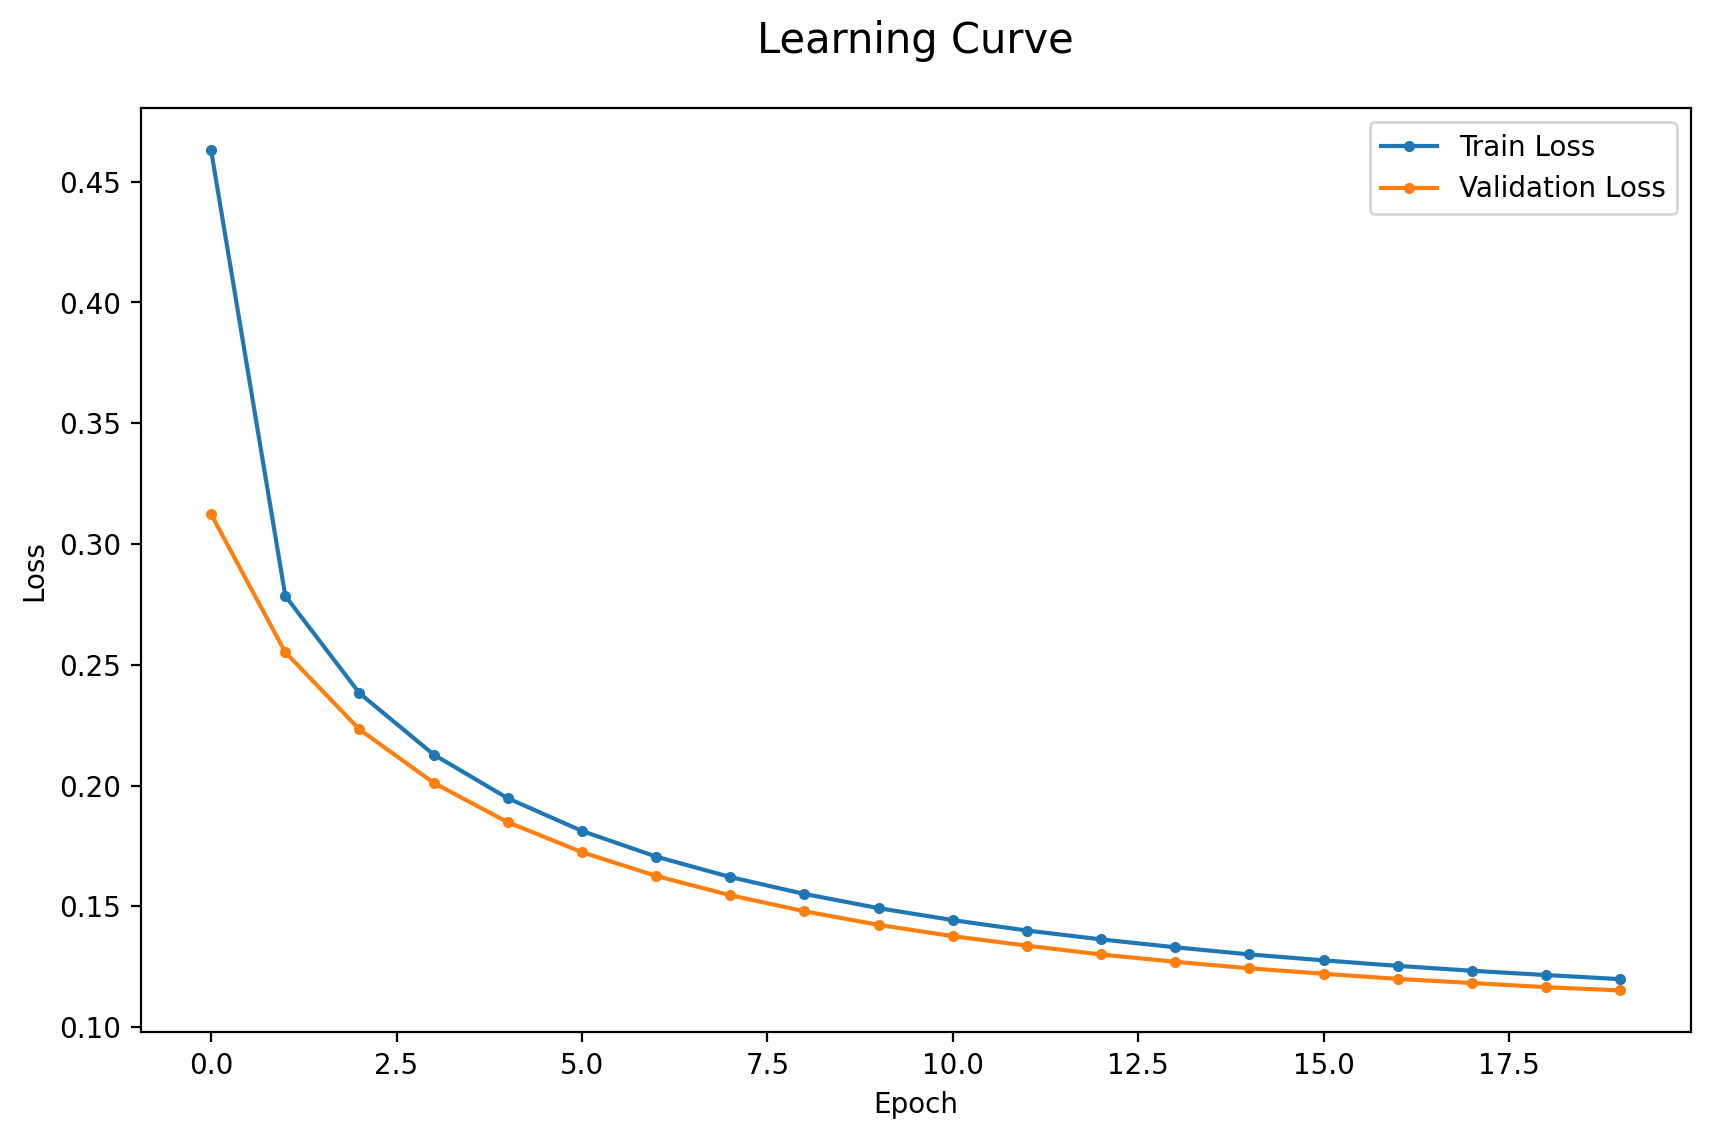

In [ ]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
# 예측
y_pred1 = model1.predict(x_val)
y_pred1 = np.where(y_pred1 >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# 성능 평가
print(confusion_matrix(y_val, y_pred1))
print('-'*60)
print(classification_report(y_val, y_pred1))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred1))

[[ 259  138]
 [  45 3414]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.65      0.74       397
           1       0.96      0.99      0.97      3459

    accuracy                           0.95      3856
   macro avg       0.91      0.82      0.86      3856
weighted avg       0.95      0.95      0.95      3856

------------------------------------------------------------
Accuracy: 0.9525414937759336


### (2) 모델 2

- 모델을 선언합니다.

In [ ]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
model2 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        47,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,209 (868.00 KB)

 Trainable params: 222,209 (868.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 학습 설정
model2.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

# 모델 학습
hist = model2.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2, verbose=1).history

Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.1500 - val_loss: 0.1024
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0833 - val_loss: 0.0900
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0665 - val_loss: 0.0784
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0582 - val_loss: 0.0844
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0448 - val_loss: 0.0897
Epoch 6/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0416 - val_loss: 0.0918
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0325 - val_loss: 0.1329
Epoch 8/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0265 - val_loss: 0.1306
Epoch 9/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.1410
Epoch 10/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0180 - val_loss: 0.1588
Epoch 11/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0172 - val_loss: 0.1208
Epoch 12/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

- 학습 곡선을 확인합니다.

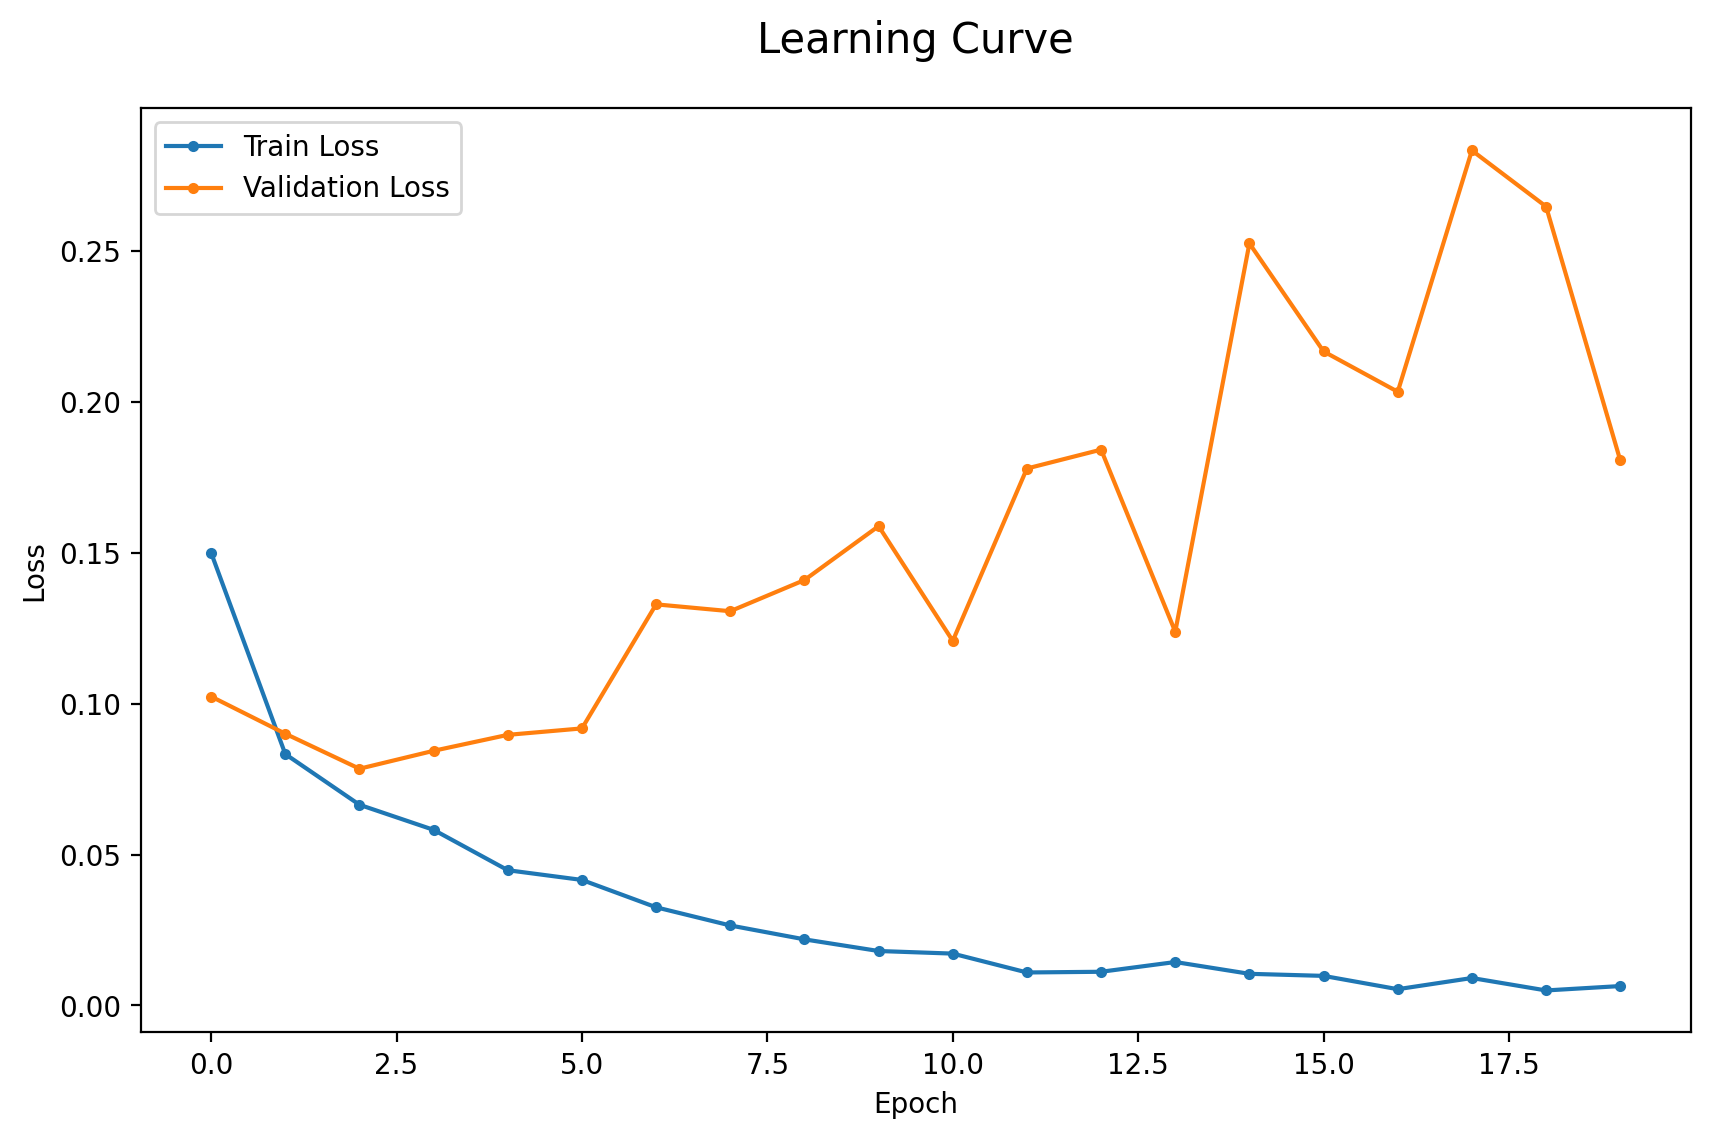

In [ ]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
# 예측
y_pred2 = model2.predict(x_val)
y_pred2 = np.where(y_pred2 >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# 성능 평가
print(confusion_matrix(y_val, y_pred2))
print('-'*60)
print(classification_report(y_val, y_pred2))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred2))

[[ 300   97]
 [  62 3397]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       397
           1       0.97      0.98      0.98      3459

    accuracy                           0.96      3856
   macro avg       0.90      0.87      0.88      3856
weighted avg       0.96      0.96      0.96      3856

------------------------------------------------------------
Accuracy: 0.9587655601659751


### (3) 모델 3: Dropout

- 모델을 선언합니다.

In [ ]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언 0.3을 줘서 뉴련은 30프로 꺼버립니다
model3 = Sequential([
    Input(shape=(nfeatures, )),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 모델 요약
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 학습 설정
model3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

# 모델 학습
hist = model3.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2, verbose=1).history

Epoch 1/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.2126 - val_loss: 0.1154
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1164 - val_loss: 0.0943
Epoch 3/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0943 - val_loss: 0.0867
Epoch 4/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0859 - val_loss: 0.0875
Epoch 5/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0746 - val_loss: 0.0823
Epoch 6/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0666 - val_loss: 0.0874
Epoch 7/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0623 - val_loss: 0.0828
Epoch 8/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0560 - val_loss: 0.0883
Epoch 9/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0538 - val_loss: 0.0976
Epoch 10/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0528 - val_loss: 0.0912
Epoch 11/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0455 - val_loss: 0.1031
Epoch 12/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

- 학습 곡선을 확인합니다.

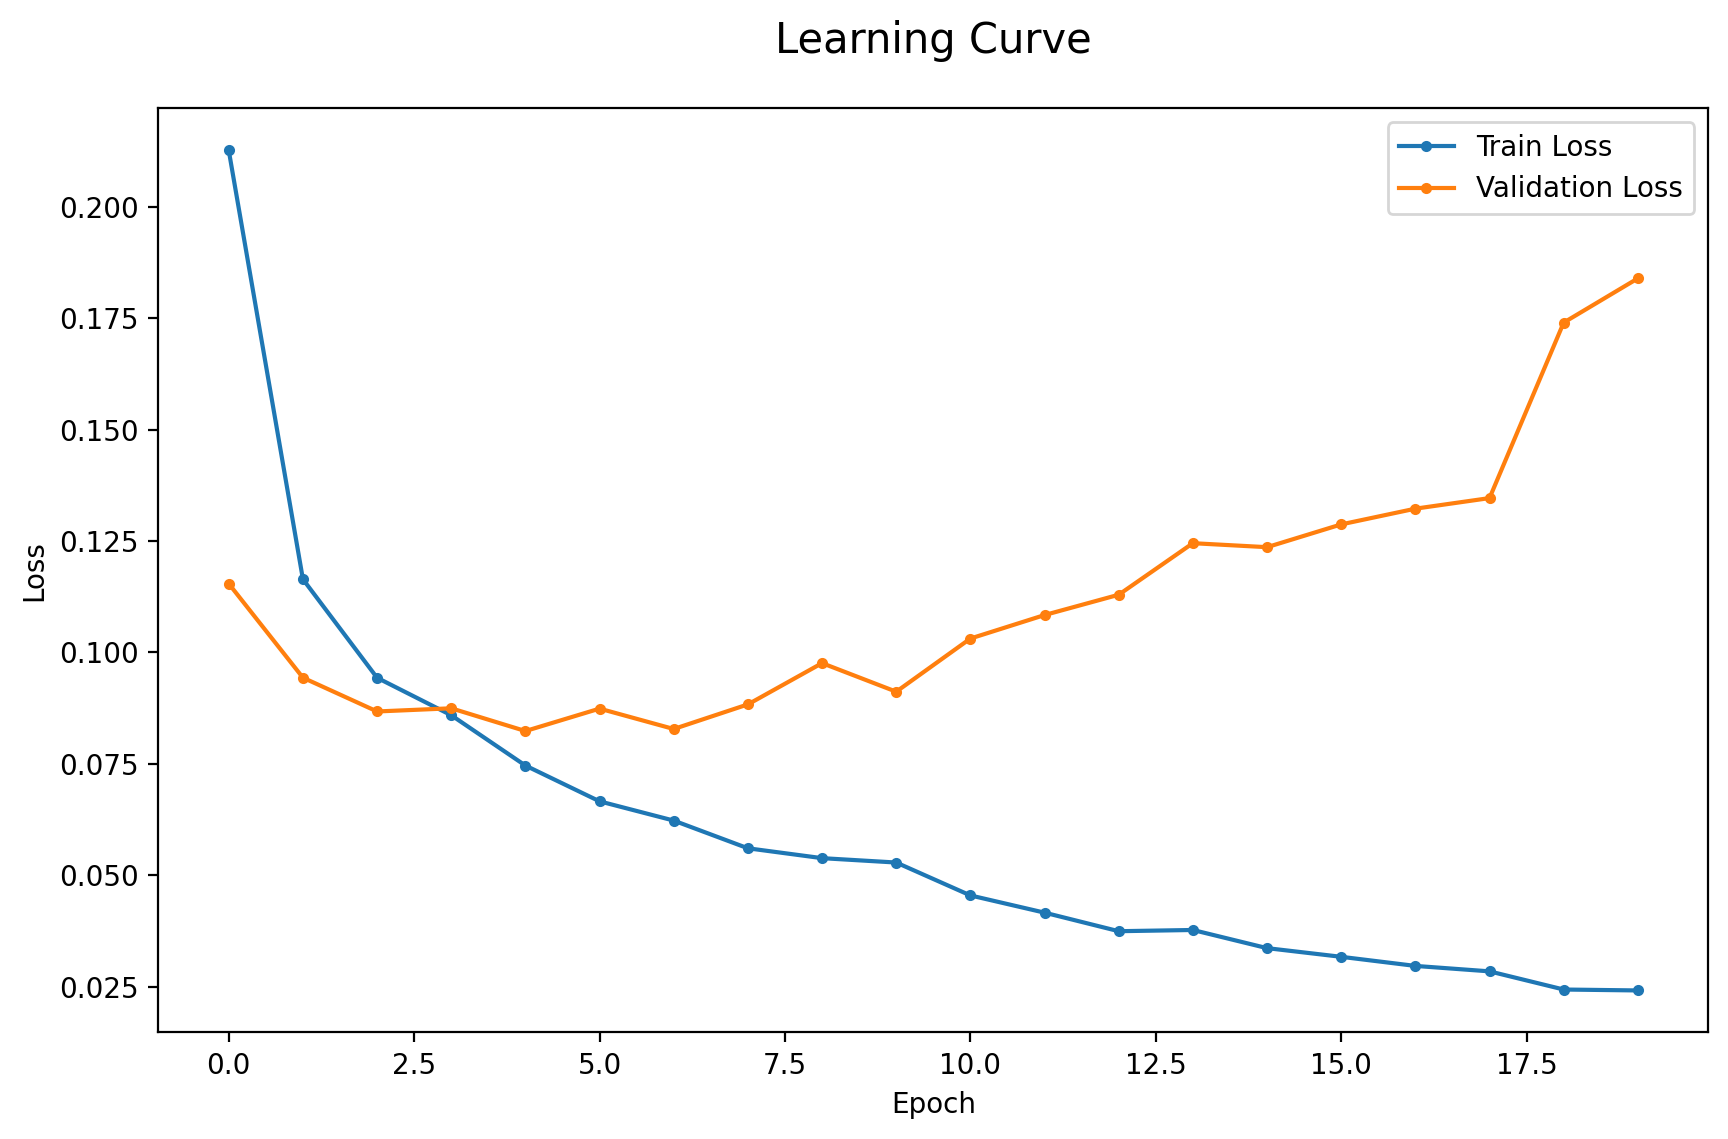

In [ ]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측을 수행하고 성능을 확인합니다.

In [ ]:
# 예측
y_pred3 = model3.predict(x_val)
y_pred3 = np.where(y_pred3 >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
# 성능 평가
print(confusion_matrix(y_val, y_pred3))
print('-'*60)
print(classification_report(y_val, y_pred3))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred3))

[[ 307   90]
 [  66 3393]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.77      0.80       397
           1       0.97      0.98      0.98      3459

    accuracy                           0.96      3856
   macro avg       0.90      0.88      0.89      3856
weighted avg       0.96      0.96      0.96      3856

------------------------------------------------------------
Accuracy: 0.9595435684647303


### (4) 모델 4: Early Stopping

- 모델을 선언합니다.

In [ ]:
# 메모리 정리
clear_session()

# 입력 Feature 수
nfeatures = x_train.shape[1]

# Sequential 모델 선언
model4 = Sequential([
    Input(shape=(nfeatures, )),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# 모델 요약
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,273 (87.00 KB)

 Trainable params: 22,273 (87.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 학습 설정
model4.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')
es = EarlyStopping(monitor='val_loss', min_delta=0.01, patience=10, verbose=1)

# 모델 학습
hist = model4.fit(x_train, y_train, batch_size=64, epochs=30, validation_split=0.2, callbacks=[es], verbose=1).history

Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1969 - val_loss: 0.1254
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0995 - val_loss: 0.0972
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0837 - val_loss: 0.0915
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0711 - val_loss: 0.0904
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0600 - val_loss: 0.1005
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0523 - val_loss: 0.1063
Epoch 7/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0451 - val_loss: 0.0988
Epoch 8/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0378 - val_loss: 0.1150
Epoch 9/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0326 - val_loss: 0.1240
Epoch 10/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0283 - val_loss: 0.1228
Epoch 11/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0216 - val_loss: 0.1459
Epoch 12/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

- 학습 곡선을 확인합니다.

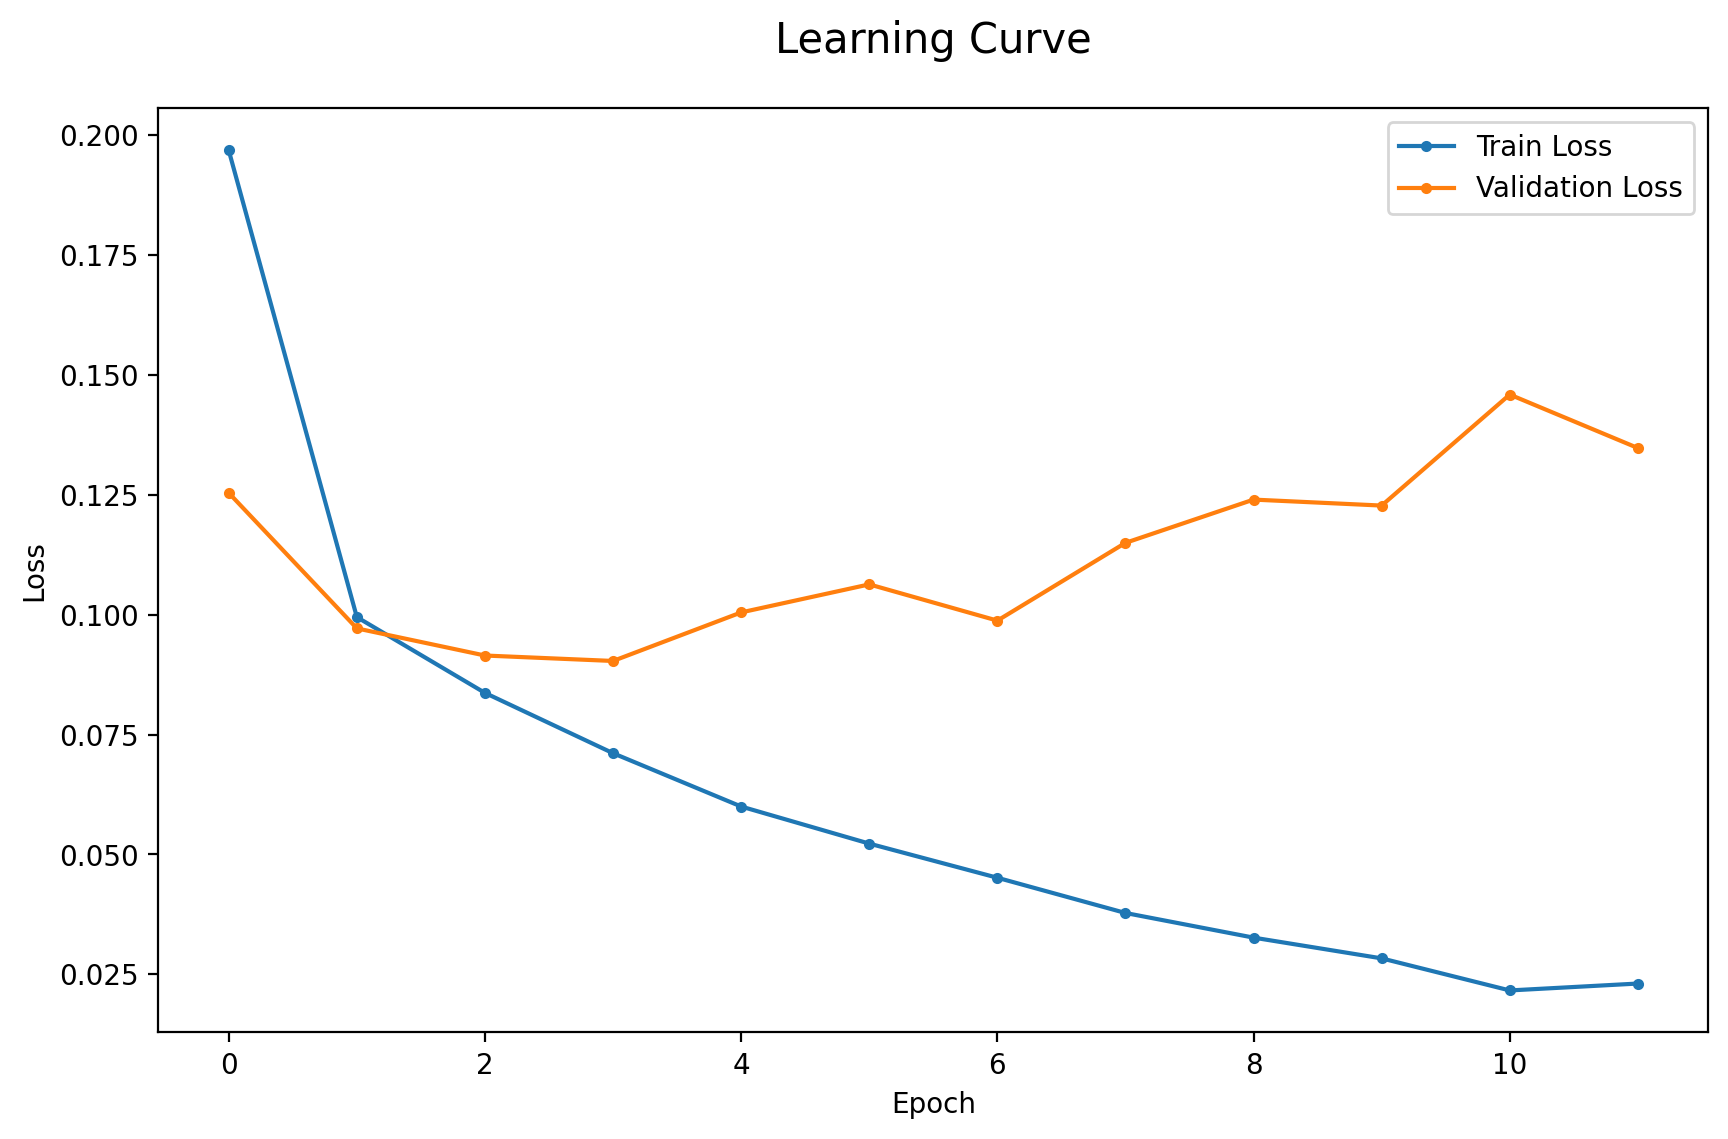

In [ ]:
# 학습 곡선
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
# 예측
y_pred4 = model4.predict(x_val)
y_pred4 = np.where(y_pred4 >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# 성능 평가
print(confusion_matrix(y_val, y_pred4))
print('-'*60)
print(classification_report(y_val, y_pred4))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred4))

[[ 301   96]
 [  50 3409]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.76      0.80       397
           1       0.97      0.99      0.98      3459

    accuracy                           0.96      3856
   macro avg       0.92      0.87      0.89      3856
weighted avg       0.96      0.96      0.96      3856

------------------------------------------------------------
Accuracy: 0.9621369294605809


In [ ]:
print('mdoel1 :', accuracy_score(y_val, y_pred1))

print('model2 :', accuracy_score(y_val, y_pred2))

print('model3 :', accuracy_score(y_val, y_pred3))

print('model4 :', accuracy_score(y_val, y_pred4))

mdoel1 : 0.9525414937759336
model2 : 0.9587655601659751
model3 : 0.9595435684647303
model4 : 0.9621369294605809


In [ ]:
#from imblearn.over_sampling import RandomOverSampler
# 오버샘플링 객체 생성
#ros = RandomOverSampler()
#x_train_ros, y_train_ros = ros.fit_resample(x_train, y_train)

##모델5
dropout과 earlystopping을 둘다 적용하여 만들어봄

In [ ]:
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# 메모리 정리
clear_session()

#오버샘플링
ros = RandomOverSampler(sampling_strategy=0.3, random_state=42)
x_train_over, y_train_over = ros.fit_resample(x_train, y_train)

# 입력 Feature 수
nfeatures = x_train_over.shape[1]

# Sequential 모델 선언 0.2을 줘서 뉴련은 20프로 꺼버립니다
model5 = Sequential([
    Input(shape=(nfeatures, )),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

# 모델 요약
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습 설정
model5.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', min_delta=0.001, restore_best_weights=True, patience=8, verbose=1)

In [ ]:
# 모델 학습
hist = model5.fit(x_train_over, y_train_over, batch_size=16, epochs=60, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

Epoch 1/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8925 - loss: 0.2570 - val_accuracy: 0.9479 - val_loss: 0.1365
Epoch 2/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9418 - loss: 0.1504 - val_accuracy: 0.9567 - val_loss: 0.1145
Epoch 3/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9487 - loss: 0.1272 - val_accuracy: 0.9575 - val_loss: 0.1126
Epoch 4/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9561 - loss: 0.1118 - val_accuracy: 0.9570 - val_loss: 0.1094
Epoch 5/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9594 - loss: 0.1000 - val_accuracy: 0.9645 - val_loss: 0.1005
Epoch 6/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9626 - loss: 0.0898 - val_accuracy: 0.9660 - val_loss: 0.0980
Epoch 7/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9659 - loss: 0.0833 - val_accuracy: 0.9629 - val_loss: 0.1026
Epoch 8/60
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9677 - loss: 0.0766 - 

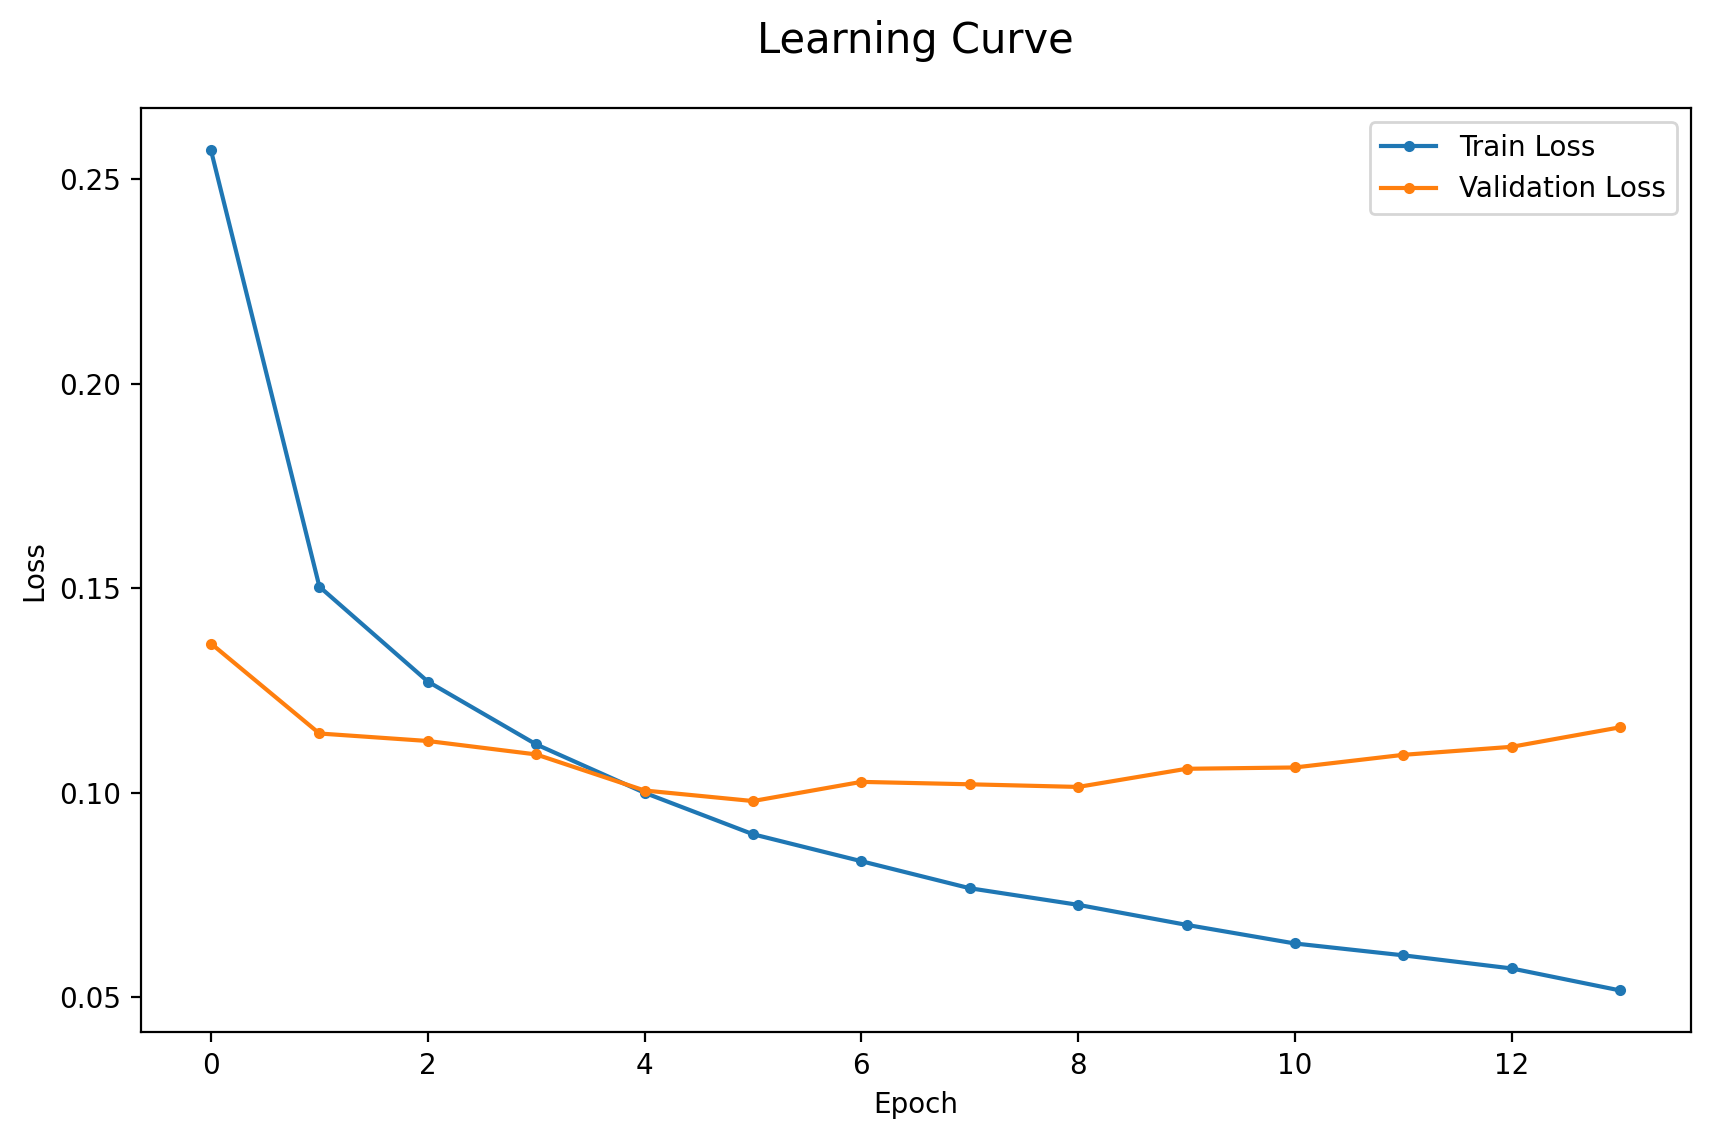

In [ ]:
# 학습 곡선
dl_history_plot(hist)

In [ ]:
# 예측
y_pred5 = model5.predict(x_val)
y_pred5 = np.where(y_pred5 >= 0.5, 1, 0)

121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# 성능 평가
print(confusion_matrix(y_val, y_pred5))
print('-'*60)
print(classification_report(y_val, y_pred5))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred5))

[[ 323   74]
 [  57 3402]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       397
           1       0.98      0.98      0.98      3459

    accuracy                           0.97      3856
   macro avg       0.91      0.90      0.91      3856
weighted avg       0.97      0.97      0.97      3856

------------------------------------------------------------
Accuracy: 0.9660269709543569


In [ ]:
print('mdoel1 :', accuracy_score(y_val, y_pred1))

print('model2 :', accuracy_score(y_val, y_pred2))

print('model3 :', accuracy_score(y_val, y_pred3))

print('model4 :', accuracy_score(y_val, y_pred4))

print('model5 :', accuracy_score(y_val, y_pred5))

mdoel1 : 0.9525414937759336
model2 : 0.9587655601659751
model3 : 0.9595435684647303
model4 : 0.9621369294605809
model5 : 0.9660269709543569


### (5) 저장

- 학습용 데이터 스케일링에 사용한 스케일러를 **scaler.pkl** 파일로 저장합니다.
- **joblib.dump()** 함수를 사용합니다.

In [ ]:
# 스케일러 저장
joblib.dump(scaler, path + 'scaler.pkl')

['/content/drive/MyDrive/project01/scaler.pkl']

- 성능이 가장 높은 모델을 **base_model.keras** 파일로 저장합니다.
- **save()** 메서드를 사용합니다.

In [ ]:
# 모델 저장
model5.save(path + 'base_model.keras')